
<h1 style='text-align:center;
           color:#C2185B;
           font-size:40px;
           font-family:Arial;'>

A DATA SCIENCE APPROACH TO PROFILING ONLINE DATERS ACCORDING TO AGE & GENERATION

</h1>

<h3 style='text-align:center;
           color:#555;
           font-family:Arial;'>

Regression & Classification with NLP & Deep Learning

</h3>


<h2 style='color:#7B1113;
           font-family:Arial;
           font-size:26px;'>

Project Objectives

</h2><ul style='font-size:15px;
           line-height:1.8;
           font-family:Arial;
           color:#333;'>
<li>
Can a dating profile predict a user’s age?
(Regression Problem)
</li>
<li>
Can a dating profile predict a user’s generation?
(Classification Problem)
</li>
<li>
Apply Natural Language Processing and Deep Learning techniques
to analyze online dating profiles.
</li>
<li>
Compare regression and classification performance using machine learning models.
</li>
</ul>


In [97]:
# IMPORT LIBRARIES

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import neattext.functions as nfx

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score)

# Classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix)

In [99]:
# READ DATASET
df = pd.read_csv("profiles.csv")
df.head()

C:\Users\zbeun\AppData\Local\Temp\ipykernel_3180\1280684353.py:2: DtypeWarning: Columns (1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,19,20,21,22,23,24,25,26,27,28,29,30) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("profiles.csv")


,age,body_type,diet,drinks,drugs,education,essay0,essay1,essay2,essay3,...,location,offspring,orientation,pets,religion,sex,sign,smokes,speaks,status
0,22.0,a little extra,strictly anything,socially,never,working on college/university,about me:<br />\n<br />\ni would love to think...,currently working as an international agent fo...,making people laugh.<br />\nranting about a go...,"the way i look. i am a six foot half asian, ha...",...,"south san francisco, california","doesn&rsquo;t have kids, but might want them",straight,likes dogs and likes cats,agnosticism and very serious about it,m,gemini,sometimes,english,single
1,35.0,average,mostly other,often,sometimes,working on space camp,i am a chef: this is what that means.<br />\n1...,dedicating everyday to being an unbelievable b...,being silly. having ridiculous amonts of fun w...,NaN,...,"oakland, california","doesn&rsquo;t have kids, but might want them",straight,likes dogs and likes cats,agnosticism but not too serious about it,m,cancer,no,"english (fluently), spanish (poorly), french (...",single
2,38.0,thin,anything,socially,NaN,graduated from masters program,"i'm not ashamed of much, but writing public te...","i make nerdy software for musicians, artists, ...",improvising in different contexts. alternating...,my large jaw and large glasses are the physica...,...,"san francisco, california",NaN,straight,has cats,NaN,m,pisces but it doesn&rsquo;t matter,no,"english, french, c++",available
3,23.0,thin,vegetarian,socially,NaN,working on college/university,i work in a library and go to school. . .,reading things written by old dead people,playing synthesizers and organizing books acco...,socially awkward but i do my best,...,"berkeley, california",doesn&rsquo;t want kids,straight,likes cats,NaN,m,pisces,no,"english, german (poorly)",single
4,29.0,athletic,NaN,socially,never,graduated from college/university,hey how's it going? currently vague on the pro...,work work work work + play,creating imagery to look at:<br />\nhttp://bag...,i smile a lot and my inquisitive nature,...,"san francisco, california",NaN,straight,likes dogs and likes cats,NaN,m,aquarius,no,english,single


In [100]:
df.tail(30)

,age,body_type,diet,drinks,drugs,education,essay0,essay1,essay2,essay3,...,location,offspring,orientation,pets,religion,sex,sign,smokes,speaks,status
60522,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
60523,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
60524,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
60525,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
60526,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
60527,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
60528,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
60529,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
60530,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
60531,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [101]:
# REMOVE FULLY EMPTY ROWS
df = df.dropna(how="all")
print(df.shape)

(9514, 31)


In [102]:
# Missing Values

df.isnull().sum().sort_values(ascending=False)

offspring      5628
diet           3753
religion       3253
pets           3162
essay8         3153
drugs          2299
essay6         2162
essay7         1961
essay9         1960
essay3         1824
sign           1738
essay5         1700
essay4         1635
essay2         1465
job            1331
essay1         1167
education      1055
ethnicity       949
smokes          918
body_type       848
essay0          847
drinks          502
speaks            6
sex               0
age               0
orientation       0
location          0
last_online       0
income            0
height            0
status            0
dtype: int64

In [103]:
# FEATURE SELECTION

selected_columns = [
    "age",
    "sex",
    "orientation",
    "essay0",
    "essay1",
    "essay2"]

df = df[selected_columns]

df.head()

,age,sex,orientation,essay0,essay1,essay2
0,22.0,m,straight,about me:<br />\n<br />\ni would love to think...,currently working as an international agent fo...,making people laugh.<br />\nranting about a go...
1,35.0,m,straight,i am a chef: this is what that means.<br />\n1...,dedicating everyday to being an unbelievable b...,being silly. having ridiculous amonts of fun w...
2,38.0,m,straight,"i'm not ashamed of much, but writing public te...","i make nerdy software for musicians, artists, ...",improvising in different contexts. alternating...
3,23.0,m,straight,i work in a library and go to school. . .,reading things written by old dead people,playing synthesizers and organizing books acco...
4,29.0,m,straight,hey how's it going? currently vague on the pro...,work work work work + play,creating imagery to look at:<br />\nhttp://bag...


In [104]:
df.tail(30)

,age,sex,orientation,essay0,essay1,essay2
9484,28.0,f,straight,"new to sf, new to the online thing....just try...",just moved in san francisco in january for wor...,making people laugh.
9485,34.0,f,straight,"i'm a botanist who loves travel, hiking, photo...",working to live not living to work.,NaN
9486,31.0,f,straight,NaN,currently i am working towards making my dream...,some fun facts:<br />\n-ping pong (yup i am a ...
9487,59.0,m,gay,having a bit of empty nest syndrome. trying to...,under construction,under construction
9488,18.0,m,straight,self summary? how can i summarize a life that ...,"im enjoying every last waking moment of it, re...","anything to do with my hands. that, and making..."
9489,42.0,f,straight,"a little bit about me: i am fun, energetic, ro...",i work in marketing at a high tech company. th...,i'm good at speaking languages and have 4 unde...
9490,24.0,f,straight,"""i'm just an animal looking for a home.""","travelling, breathing, walking, running, laugh...","laughing, hanging, cartwheels, and rock, paper..."
9491,31.0,f,straight,i am a college lecturer who used to be a balle...,right now i am trying to find a permanent job ...,"teaching, dancing, and yoga"
9492,20.0,m,straight,at the moment i cant summarize myself i'll try...,"trying to figure it all out, oh and im really ...",going off topic for no reason. oh and pointing...
9493,34.0,f,straight,i skittered into the bay area over a year ago ...,i'm a big nerd about what i love: my professio...,"remembering useless trivia, identifying typogr..."


In [105]:
df.isnull().sum().sort_values(ascending=False)

essay2         1465
essay1         1167
essay0          847
age               0
sex               0
orientation       0
dtype: int64

In [106]:
# COMBINE ESSAYS
df["profile_text"] = (
    df["essay0"].fillna("") + " " +
    df["essay1"].fillna("") + " " +
    df["essay2"].fillna(""))

In [107]:
# REMOVE EXTRA SPACES

df["profile_text"] = (
    df["profile_text"]
    .str.replace(r"\s+", " ", regex=True)
    .str.strip())

In [108]:
df[["essay0", "essay1", "essay2", "profile_text"]].head()

,essay0,essay1,essay2,profile_text
0,about me:<br />\n<br />\ni would love to think...,currently working as an international agent fo...,making people laugh.<br />\nranting about a go...,about me:<br /> <br /> i would love to think t...
1,i am a chef: this is what that means.<br />\n1...,dedicating everyday to being an unbelievable b...,being silly. having ridiculous amonts of fun w...,i am a chef: this is what that means.<br /> 1....
2,"i'm not ashamed of much, but writing public te...","i make nerdy software for musicians, artists, ...",improvising in different contexts. alternating...,"i'm not ashamed of much, but writing public te..."
3,i work in a library and go to school. . .,reading things written by old dead people,playing synthesizers and organizing books acco...,i work in a library and go to school. . . read...
4,hey how's it going? currently vague on the pro...,work work work work + play,creating imagery to look at:<br />\nhttp://bag...,hey how's it going? currently vague on the pro...


In [109]:
print(df["profile_text"].head()) ##Essay'ler profile_text ile birleştirildi

0    about me:<br /> <br /> i would love to think t...
1    i am a chef: this is what that means.<br /> 1....
2    i'm not ashamed of much, but writing public te...
3    i work in a library and go to school. . . read...
4    hey how's it going? currently vague on the pro...
Name: profile_text, dtype: object


In [110]:
print(df["profile_text"].iloc[0])

about me:<br /> <br /> i would love to think that i was some some kind of intellectual: either the dumbest smart guy, or the smartest dumb guy. can't say i can tell the difference. i love to talk about ideas and concepts. i forge odd metaphors instead of reciting cliches. like the simularities between a friend of mine's house and an underwater salt mine. my favorite word is salt by the way (weird choice i know). to me most things in life are better as metaphors. i seek to make myself a little better everyday, in some productively lazy way. got tired of tying my shoes. considered hiring a five year old, but would probably have to tie both of our shoes... decided to only wear leather shoes dress shoes.<br /> <br /> about you:<br /> <br /> you love to have really serious, really deep conversations about really silly stuff. you have to be willing to snap me out of a light hearted rant with a kiss. you don't have to be funny, but you have to be able to make me laugh. you should be able to b

In [111]:
print(df.columns)

Index(['age', 'sex', 'orientation', 'essay0', 'essay1', 'essay2',
       'profile_text'],
      dtype='object')


In [112]:
df[["essay0", "essay1", "essay2", "profile_text"]].iloc[0]

essay0          about me:<br />\n<br />\ni would love to think...
essay1          currently working as an international agent fo...
essay2          making people laugh.<br />\nranting about a go...
profile_text    about me:<br /> <br /> i would love to think t...
Name: 0, dtype: object

### TEXT CLEANING 

In [113]:
import neattext.functions as nfx

df["clean_text"] = df["profile_text"].str.lower()

df["clean_text"] = df["clean_text"].apply(
    nfx.remove_punctuations)

df["clean_text"] = df["clean_text"].apply(
    nfx.remove_special_characters)

df["clean_text"] = df["clean_text"].apply(
    nfx.remove_stopwords)

df[["profile_text", "clean_text"]].head()

,profile_text,clean_text
0,about me:<br /> <br /> i would love to think t...,mebr br love think kind intellectual dumbest s...
1,i am a chef: this is what that means.<br /> 1....,chef meansbr 1 workaholicbr 2 love cook regard...
2,"i'm not ashamed of much, but writing public te...",im ashamed writing public text online dating s...
3,i work in a library and go to school. . . read...,work library school reading things written old...
4,hey how's it going? currently vague on the pro...,hey hows going currently vague profile know co...


In [115]:
# GENERATION LABEL ENCODING
def generation_label(age):

    if 18 <= age <= 32:
        return "Millennial"

    elif 33 <= age <= 47:
        return "Gen X"

    else:
        return "Boomer"
df["generation"] = df["age"].apply(
    generation_label)

df[["age", "generation"]].head()

,age,generation
0,22.0,Millennial
1,35.0,Gen X
2,38.0,Gen X
3,23.0,Millennial
4,29.0,Millennial


### Age Distribution Analysis

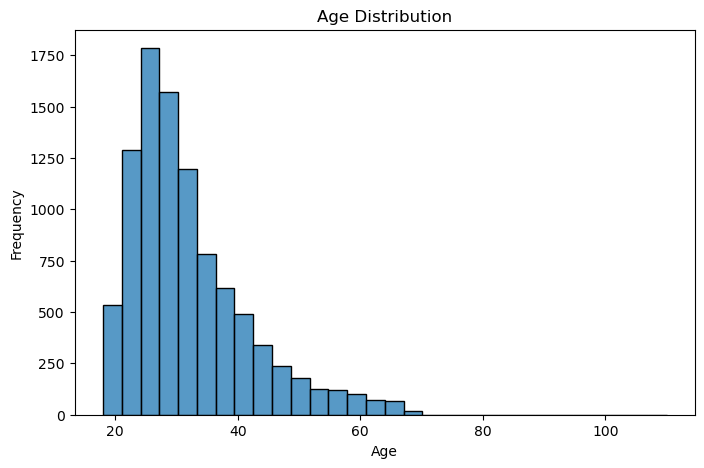

In [116]:
plt.figure(figsize=(8,5))

sns.histplot(df["age"], bins=30)

plt.title("Age Distribution")

plt.xlabel("Age")

plt.ylabel("Frequency")

plt.show()

In [117]:
df["age"].describe()

count    9514.000000
mean       32.084192
std         9.445488
min        18.000000
25%        25.000000
50%        30.000000
75%        36.000000
max       110.000000
Name: age, dtype: float64

### Observation:
#### Most users are concentrated between their 20s and 40s.
#### Younger age groups appear more frequently in the dataset.

### Regression Workflow (Age Prediction)
#### 1-Clean_text
#### 2- TF-IDF
#### 3-Train-Test Split
#### 4-Regression Model
#### 5-Evaluation

In [118]:
# REGRESSION FEATURE & TARGET

X_reg = df["clean_text"]

y_reg = df["age"]

In [119]:
# TF-IDF VECTORIZATION

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_reg = TfidfVectorizer(max_features=5000)

X_reg_tfidf = tfidf_reg.fit_transform(X_reg)

print(X_reg_tfidf.shape)

(9514, 5000)


In [120]:
# TRAIN TEST SPLIT

from sklearn.model_selection import train_test_split

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg_tfidf,
    y_reg,
    test_size=0.20,
    random_state=42)


In [121]:
# LINEAR REGRESSION MODEL

from sklearn.linear_model import LinearRegression

reg_model = LinearRegression()

reg_model.fit(X_train_reg, y_train_reg)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [122]:
# AGE PREDICTION

y_pred_reg = reg_model.predict(X_test_reg)

In [123]:
# REGRESSION EVALUATION

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score)

mae = mean_absolute_error(y_test_reg, y_pred_reg)

mse = mean_squared_error(y_test_reg, y_pred_reg)

rmse = np.sqrt(mse)

r2 = r2_score(y_test_reg, y_pred_reg)

print("MAE:", mae)

print("MSE:", mse)

print("RMSE:", rmse)

print("R2 Score:", r2)

MAE: 9.531643465338508
MSE: 147.0189356421902
RMSE: 12.12513652055886
R2 Score: -0.6176377274918996


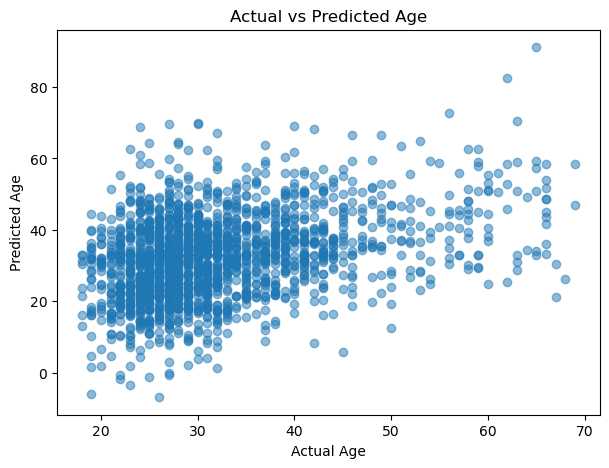

In [124]:
# ACTUAL VS PREDICTED AGES

plt.figure(figsize=(7,5))

plt.scatter(y_test_reg, y_pred_reg, alpha=0.5)

plt.xlabel("Actual Age")

plt.ylabel("Predicted Age")

plt.title("Actual vs Predicted Age")

plt.show()

### Classification Feature & Target

In [125]:
X_cls = df["clean_text"]

y_cls = df["generation"]

In [126]:
# TF-IDF VECTORIZATION

tfidf_cls = TfidfVectorizer(max_features=5000)

X_cls_tfidf = tfidf_cls.fit_transform(X_cls)

print(X_cls_tfidf.shape)

(9514, 5000)


In [127]:
# TRAIN TEST SPLIT
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls_tfidf,
    y_cls,
    test_size=0.20,
    random_state=42,
    stratify=y_cls)

In [128]:
print(y_train_cls.value_counts())

generation
Millennial    4837
Gen X         2177
Boomer         597
Name: count, dtype: int64


In [129]:
# APPLY SMOTE

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_cls,
    y_train_cls)

print(pd.Series(y_train_smote).value_counts())

generation
Gen X         4837
Boomer        4837
Millennial    4837
Name: count, dtype: int64


In [130]:
# LOGISTIC REGRESSION MODEL

cls_model = LogisticRegression(max_iter=1000)

cls_model.fit(X_train_smote, y_train_smote)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [131]:
# GENERATION PREDICTION

y_pred_cls = cls_model.predict(X_test_cls)

In [132]:
# CLASSIFICATION EVALUATION

print("Accuracy Score:")

print(accuracy_score(y_test_cls, y_pred_cls))

print("\nClassification Report:\n")

print(classification_report(y_test_cls, y_pred_cls))

Accuracy Score:
0.6442459274829218

Classification Report:

              precision    recall  f1-score   support

      Boomer       0.30      0.63      0.41       149
       Gen X       0.49      0.45      0.47       544
  Millennial       0.82      0.73      0.77      1210

    accuracy                           0.64      1903
   macro avg       0.53      0.60      0.55      1903
weighted avg       0.68      0.64      0.66      1903



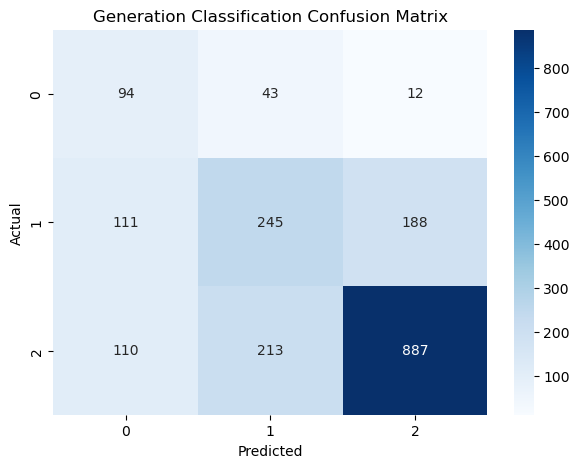

In [133]:
# CONFUSION MATRIX

plt.figure(figsize=(7,5))

sns.heatmap(
    confusion_matrix(y_test_cls, y_pred_cls),
    annot=True,
    fmt="d",
    cmap="Blues")

plt.title("Generation Classification Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

<Axes: xlabel='age', ylabel='Count'>

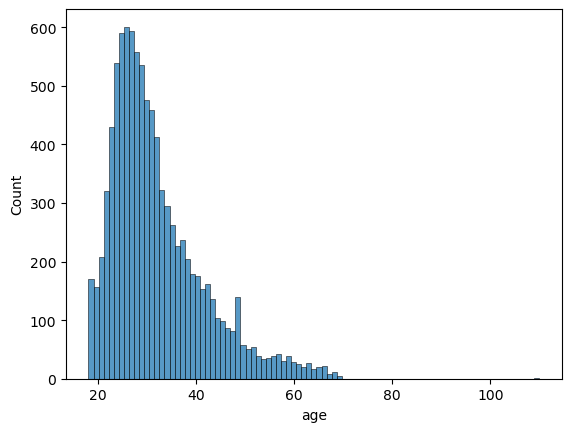

In [134]:
sns.histplot(df["age"])

In [135]:
# GENERATION LABEL ENCODING

def generation_label(age):

    if 18 <= age <= 32:
        return "Millennial"

    elif 33 <= age <= 47:
        return "Gen X"

    else:
        return "Boomer"


df["generation"] = df["age"].apply(
    generation_label
)

df[["age", "generation"]].head()

,age,generation
0,22.0,Millennial
1,35.0,Gen X
2,38.0,Gen X
3,23.0,Millennial
4,29.0,Millennial


In [136]:
# LABEL ENCODING

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y_encoded = encoder.fit_transform(df["generation"])

print(encoder.classes_)

['Boomer' 'Gen X' 'Millennial']


In [137]:
# TF-IDF

X = df["clean_text"]

tfidf_dl = TfidfVectorizer(max_features=5000)

X_tfidf_dl = tfidf_dl.fit_transform(X).toarray()

In [138]:
# TRAIN TEST SPLIT

X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(
    X_tfidf_dl,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded)

In [139]:
# DEEP LEARNING MODEL

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential()

model.add(Dense(128, activation="relu", input_shape=(5000,)))

model.add(Dropout(0.3))

model.add(Dense(64, activation="relu"))

model.add(Dropout(0.3))

model.add(Dense(3, activation="softmax"))

C:\Users\zbeun\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [140]:
# COMPILE MODEL

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"])

In [141]:
# TRAIN MODEL

history = model.fit(
    X_train_dl,
    y_train_dl,
    epochs=10,
    batch_size=32,
    validation_split=0.2)

Epoch 1/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.6396 - loss: 0.8069 - val_accuracy: 0.7012 - val_loss: 0.6550
Epoch 2/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.7456 - loss: 0.5718 - val_accuracy: 0.7157 - val_loss: 0.6456
Epoch 3/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.8426 - loss: 0.3960 - val_accuracy: 0.7085 - val_loss: 0.7293
Epoch 4/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9083 - loss: 0.2523 - val_accuracy: 0.6802 - val_loss: 0.8826
Epoch 5/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9502 - loss: 0.1493 - val_accuracy: 0.6756 - val_loss: 1.0700
Epoch 6/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9676 - loss: 0.0948 - val_accuracy: 0.6664 - val_loss: 1.3034
Epoch 7/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9755 - loss: 0.0712 - val_accuracy: 0.6691 - val_loss: 1.4481
Epoch 8/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.9782 - loss: 0.0603 - val_accu

In [142]:
# MODEL EVALUATION

loss, accuracy = model.evaluate(
    X_test_dl,
    y_test_dl)

print("Test Accuracy:", accuracy)

60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6348 - loss: 1.8491
Test Accuracy: 0.6347872018814087


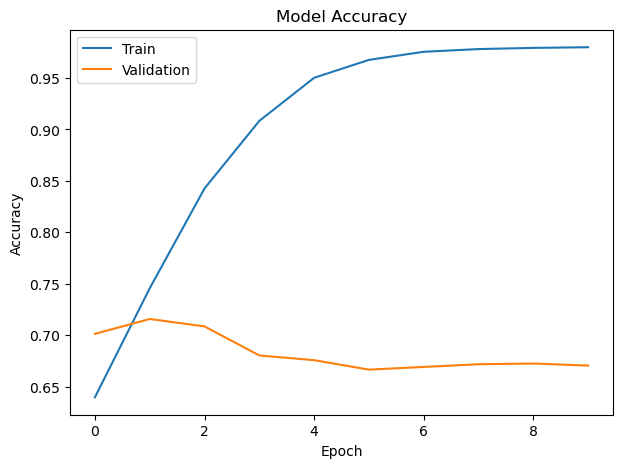

In [143]:
# ACCURACY GRAPH

plt.figure(figsize=(7,5))

plt.plot(history.history["accuracy"])

plt.plot(history.history["val_accuracy"])

plt.title("Model Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend(["Train", "Validation"])

plt.show()

### Bu grafik overfitting gösteriyor.
#### Model:Train accuracy: %97’ye çıkmış,Validation accuracy: %67 civarında kalmış
##### Yani model eğitim verisini ezberlemiş ama yeni veriye çok iyi genelleyememiş.

### HYBRID MODEL ( diğer kolonları dahil edelim)

In [145]:
# RELOAD DATASET FOR HYBRID MODEL

df_h = pd.read_csv("profiles.csv")

# Remove fully empty rows
df_h = df_h.dropna(how="all")

print(df_h.shape)
print(df_h.columns)

(9514, 31)
Index(['age', 'body_type', 'diet', 'drinks', 'drugs', 'education', 'essay0',
       'essay1', 'essay2', 'essay3', 'essay4', 'essay5', 'essay6', 'essay7',
       'essay8', 'essay9', 'ethnicity', 'height', 'income', 'job',
       'last_online', 'location', 'offspring', 'orientation', 'pets',
       'religion', 'sex', 'sign', 'smokes', 'speaks', 'status'],
      dtype='object')


C:\Users\zbeun\AppData\Local\Temp\ipykernel_3180\2537482191.py:3: DtypeWarning: Columns (1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,19,20,21,22,23,24,25,26,27,28,29,30) have mixed types. Specify dtype option on import or set low_memory=False.
  df_h = pd.read_csv("profiles.csv")


In [146]:
# SELECT HYBRID FEATURES

selected_columns = [
    "age",
    "sex",
    "orientation",
    "education",
    "job",
    "essay0",
    "essay1",
    "essay2"]

df_h = df_h[selected_columns].copy()

In [147]:
# COMBINE ESSAYS

df_h["profile_text"] = (
    df_h["essay0"].fillna("") + " " +
    df_h["essay1"].fillna("") + " " +
    df_h["essay2"].fillna(""))

df_h["profile_text"] = (
    df_h["profile_text"]
    .str.replace(r"\s+", " ", regex=True)
    .str.strip())

df_h = df_h[df_h["profile_text"] != ""]

In [148]:
# TEXT CLEANING

df_h["clean_text"] = df_h["profile_text"].str.lower()
df_h["clean_text"] = df_h["clean_text"].apply(nfx.remove_punctuations)
df_h["clean_text"] = df_h["clean_text"].apply(nfx.remove_special_characters)
df_h["clean_text"] = df_h["clean_text"].apply(nfx.remove_stopwords)

In [149]:
# GENERATION LABEL ENCODING

def generation_label(age):
    if 18 <= age <= 32:
        return "Millennial"
    elif 33 <= age <= 47:
        return "Gen X"
    else:
        return "Boomer"

df_h["generation"] = df_h["age"].apply(generation_label)

In [150]:
# HYBRID MODEL FEATURES

hybrid_columns = [
    "clean_text",
    "sex",
    "orientation",
    "education",
    "job"]

df_hybrid = df_h[hybrid_columns + ["generation"]].copy()

df_hybrid.head()

,clean_text,sex,orientation,education,job,generation
0,mebr br love think kind intellectual dumbest s...,m,straight,working on college/university,transportation,Millennial
1,chef meansbr 1 workaholicbr 2 love cook regard...,m,straight,working on space camp,hospitality / travel,Gen X
2,im ashamed writing public text online dating s...,m,straight,graduated from masters program,NaN,Gen X
3,work library school reading things written old...,m,straight,working on college/university,student,Millennial
4,hey hows going currently vague profile know co...,m,straight,graduated from college/university,artistic / musical / writer,Millennial


In [151]:
df_h["education"] = df_h["education"].fillna("unknown")

df_h["job"] = df_h["job"].fillna("unknown")

In [152]:
# FILL MISSING CATEGORICAL VALUES

df_h["education"] = df_h["education"].fillna("unknown")
df_h["job"] = df_h["job"].fillna("unknown")
df_h["sex"] = df_h["sex"].fillna("unknown")
df_h["orientation"] = df_h["orientation"].fillna("unknown")
df_h["clean_text"] = df_h["clean_text"].fillna("")

In [153]:
# HYBRID FEATURE SELECTION

X_hybrid = df_h[["clean_text", "sex", "orientation", "education", "job"]]

y_hybrid = df_h["generation"]

X_hybrid.head()

,clean_text,sex,orientation,education,job
0,mebr br love think kind intellectual dumbest s...,m,straight,working on college/university,transportation
1,chef meansbr 1 workaholicbr 2 love cook regard...,m,straight,working on space camp,hospitality / travel
2,im ashamed writing public text online dating s...,m,straight,graduated from masters program,unknown
3,work library school reading things written old...,m,straight,working on college/university,student
4,hey hows going currently vague profile know co...,m,straight,graduated from college/university,artistic / musical / writer


In [154]:
X_hybrid.tail()

,clean_text,sex,orientation,education,job
9507,im idealistrealist means strong sense world tr...,m,straight,graduated from masters program,political / government
9508,libra looking honest relationship love walks s...,f,straight,graduated from college/university,rather not say
9509,normal guy looking age spend quality time lear...,m,straight,working on med school,medicine / health
9510,work beauty salon hairstylist years castro dis...,m,gay,unknown,hospitality / travel
9511,33 year old hiv versatile gwm bearish type tat...,m,gay,dropped out of college/university,hospitality / travel


In [156]:
# TRAIN TEST SPLIT

X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_hybrid,
    y_hybrid,
    test_size=0.20,
    random_state=42,
    stratify=y_hybrid)

In [158]:
# HYBRID PIPELINE: TF-IDF + ONE-HOT ENCODING + LOGISTIC REGRESSION

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

preprocessor = ColumnTransformer(
    transformers=[
        ("text", TfidfVectorizer(max_features=5000), "clean_text"),
        ("cat", OneHotEncoder(handle_unknown="ignore"), 
         ["sex", "orientation", "education", "job"])])

hybrid_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))])

In [159]:
# TRAIN HYBRID MODEL

hybrid_model.fit(X_train_h, y_train_h)

y_pred_h = hybrid_model.predict(X_test_h)

In [160]:
# HYBRID MODEL EVALUATION

print("Hybrid Model Accuracy:", accuracy_score(y_test_h, y_pred_h))

print("\nClassification Report:\n")
print(classification_report(y_test_h, y_pred_h))

Hybrid Model Accuracy: 0.6965365585486532

Classification Report:

              precision    recall  f1-score   support

      Boomer       0.75      0.11      0.19       141
       Gen X       0.52      0.41      0.46       518
  Millennial       0.75      0.90      0.81      1160

    accuracy                           0.70      1819
   macro avg       0.67      0.47      0.49      1819
weighted avg       0.68      0.70      0.66      1819



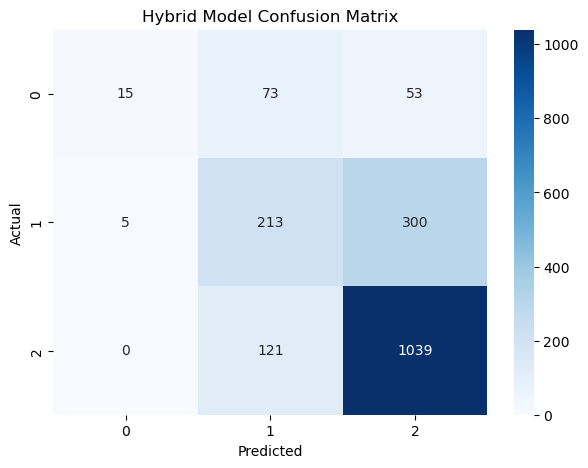

In [163]:
# HYBRID CONFUSION MATRIX

plt.figure(figsize=(7,5))

sns.heatmap(
    confusion_matrix(y_test_h, y_pred_h),
    annot=True,
    fmt="d",
    cmap="Blues")

plt.title("Hybrid Model Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Conclusion:
#### The confusion matrix shows that the hybrid model performs best
#### for the Millennial class.
#### Gen X users were classified with moderate success,
#### while the Boomer class remained more difficult to predict.
#### This may be related to class imbalance and overlapping language patterns
#### between generations.
#### Overall, the hybrid model improved classification performance
#### by combining textual and categorical features.